# It Takes Time: Intensity-Aware Sequential Recommendation Benchmark

Goal: rank a battery of sequential / temporal collaborative-filtering models on
**MovieLens-1M**, **MovieLens-100K**, and Amazon Reviews 5-core (**Digital Music**, **Office Products**) under a single, reproducible methodology, and
produce results tables that compare standard SOTA baselines against three new
**IA-SASRec** (Intensity-Aware SASRec) variants that inject per-interaction
intensity (ratings / hours-played) directly into the self-attention mechanism.

**Models compared**

| Family | Models |
|---|---|
| Non-sequential baselines | `Pop`, `BPR`, `ItemKNN` |
| Sequential SOTA | `FPMC`, `GRU4Rec`, `NARM`, `SASRec`, `BERT4Rec` |
| **IA-SASRec (new)** | `IA-SASRec-Add`, `IA-SASRec-Mul`, `IA-SASRec-Val` |

**Methodology**

- Datasets: ML-1M, ML-100K, Amazon Digital Music 5-core, Amazon Office Products 5-core.
  All four use rating as intensity and ship with native unix timestamps. Steam-200k is
  excluded from sequential experiments — its CSV has no timestamps. All datasets are
  filtered to users/items with >= 5 interactions.
- Split: leave-one-out per user, sorted chronologically (`LS=valid_and_test`, `order=TO`).
- HPO: Optuna TPE + MedianPruner, `N_TRIALS=10` by default.
- Eval: full-vocabulary scoring -> HitRate, NDCG, MRR, Recall, Precision @ {10, 20, 50, 100}.
- Resumability: results persisted to `results/eval/<dataset>__<model>.json`;
  Optuna studies persist to SQLite under `results/hpo/`.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import optuna

import config
from data import prepare_recbole_dataset, dataset_stats
from models import MODEL_REGISTRY, list_models
from hpo import run_optuna
from runner import train_and_eval, has_result, load_result
from evaluation import aggregate_results, top_k_recommend

print('device:', config.DEVICE)
print('models:', list_models())
print('N_TRIALS:', config.N_TRIALS, '| HPO_EPOCHS:', config.HPO_EPOCHS, '| FINAL_EPOCHS:', config.FINAL_EPOCHS)

2026-05-23 18:22:22.158882: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-23 18:22:22.230188: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-23 18:22:24.046934: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


device: cuda
models: ['Pop', 'BPR', 'ItemKNN', 'FPMC', 'GRU4Rec', 'NARM', 'SASRec', 'BERT4Rec', 'IA-SASRec-Add', 'IA-SASRec-Mul', 'IA-SASRec-Val']
N_TRIALS: 25 | HPO_EPOCHS: 10 | FINAL_EPOCHS: 50


## 2. Dataset preparation

Downloads MovieLens-1M (~6 MB), MovieLens-100K (~5 MB), Amazon Digital Music
5-core (~5 MB), and Amazon Office Products 5-core (~5 MB) on first run,
converts each to RecBole atomic-file format, and caches under
`recbole_data/<dataset>/<dataset>.inter`. Subsequent runs are no-ops.

In [2]:
DATASETS = ['steam-3k', 'steam-8k', 'steam-15k', 'amazon-digital-music', 'amazon-office-products', 'ml-100k-iar', 'ml-1m']
# Note: 'ml-100k-iar' (Intensity-Aware) — NOT plain 'ml-100k'.
# RecBole 1.2.0 hard-codes a special case for dataset name == 'ml-100k' that
# overrides our data_path to its bundled 3-column example file, silently
# dropping the intensity column. See src/config.py for context.
stats_all = {}
for ds in DATASETS:
    try:
        prepare_recbole_dataset(ds)
        stats_all[ds] = dataset_stats(ds)
    except Exception as e:
        print(f'[skip] {ds}: {e}')
pd.DataFrame(stats_all).style.format('{:.4f}')

,steam-3k,steam-8k,steam-15k,amazon-digital-music,amazon-office-products,ml-100k-iar,ml-1m
interactions,39450.0000,101210.0000,187004.0000,64706.0000,53258.0000,100000.0000,1000209.0000
users,3000.0000,8000.0000,15000.0000,5541.0000,4905.0000,943.0000,6040.0000
items,5754.0000,8110.0000,9446.0000,3568.0000,2420.0000,1682.0000,3706.0000
density,0.0023,0.0016,0.0013,0.0033,0.0045,0.0630,0.0447
min_ts,1287100800.0000,1287100800.0000,1287100800.0000,893721600.0000,970185600.0000,874724710.0000,956703932.0000
max_ts,1515110400.0000,1515110400.0000,1515110400.0000,1406073600.0000,1406073600.0000,893286638.0000,1046454590.0000
intensity_min,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
intensity_max,14139.9000,16793.8000,19513.6000,5.0000,5.0000,5.0000,5.0000
intensity_mean,68.4489,67.8267,68.2590,4.2225,4.3460,3.5299,3.5816


## 3. Run benchmark (resumable)

Loops the model registry. For each model:

1. If `results/eval/<dataset>__<model>.json` exists → load it, skip training.
2. Otherwise: run Optuna HPO, then a final fit on the best params, persist JSON.

Interrupt at any point; re-running this cell continues from the next un-evaluated model.

In [3]:
MODELS_TO_RUN = list_models()  # includes IA-SASRec-Add / -Mul / -Val
MODELS_TO_RUN = [m for m in MODELS_TO_RUN if 'SASRec' in m]

DATASETS_TO_RUN = [ds for ds in DATASETS if ds in stats_all]

results = {}
for ds in DATASETS_TO_RUN:
    print(f'\n########## dataset = {ds} ##########')
    for name in MODELS_TO_RUN:
        print(f'\n=== {ds} / {name} ===')
        # Recover best_params from an existing result so we can skip HPO;
        # but always call train_and_eval — it handles per-seed resumption.
        best_params = None
        if has_result(ds, name):
            existing = load_result(ds, name)
            best_params = existing.get('best_params') or {}
        if best_params is None:
            hpo_out = run_optuna(ds, name)
            print(f'  HPO best_value={hpo_out["best_value"]} params={hpo_out["best_params"]}')
            best_params = hpo_out['best_params']
        r = train_and_eval(ds, name, best_params=best_params)
        results[(ds, name)] = r
        ndcg = r["test_result"].get("ndcg@10")
        std = (r.get("test_result_std") or {}).get("ndcg@10", 0.0)
        n = r.get("n_seeds", 1)
        print(f'  final NDCG@10={ndcg:.4f} ± {std:.4f}  (n={n} seed{"s" if n > 1 else ""})')

print('\nAll done.')


########## dataset = steam-3k ##########

=== steam-3k / SASRec ===
[runner] SASRec on steam-3k (seed=2020): cached result loaded, NDCG@10=0.0375
[runner] SASRec on steam-3k (seed=2021): cached result loaded, NDCG@10=0.0364
[runner] SASRec on steam-3k (seed=2022): cached result loaded, NDCG@10=0.0337
[runner] SASRec on steam-3k (seed=2023): cached result loaded, NDCG@10=0.0328
[runner] SASRec on steam-3k (seed=2024): cached result loaded, NDCG@10=0.0346
  final NDCG@10=0.0350 ± 0.0019  (n=5 seeds)

=== steam-3k / IA-SASRec-Add ===
[runner] IA-SASRec-Add on steam-3k (seed=2020): cached result loaded, NDCG@10=0.0353
[runner] IA-SASRec-Add on steam-3k (seed=2021): cached result loaded, NDCG@10=0.0298
[runner] IA-SASRec-Add on steam-3k (seed=2022): cached result loaded, NDCG@10=0.0312
[runner] IA-SASRec-Add on steam-3k (seed=2023): cached result loaded, NDCG@10=0.0335
[runner] IA-SASRec-Add on steam-3k (seed=2024): cached result loaded, NDCG@10=0.0332
  final NDCG@10=0.0326 ± 0.0021  (n=5

## 4. Results table

In [4]:
key_cols = ['model', 'hit@10', 'ndcg@10', 'mrr@10', 'recall@10', 'hit@100', 'ndcg@100', 'train_seconds']
tables = {}
for ds in DATASETS_TO_RUN:
    df_ds = aggregate_results(ds)
    cols = [c for c in key_cols if c in df_ds.columns]
    tables[ds] = df_ds[cols].round(4)
    print(f'\n--- {ds} ---')
    print(tables[ds].to_string(index=False))


--- steam-3k ---
        model  hit@10  ndcg@10  mrr@10  recall@10  hit@100  ndcg@100  train_seconds
       SASRec  0.0688   0.0350  0.0248     0.0688   0.2530    0.0707        34.8296
IA-SASRec-Add  0.0634   0.0326  0.0233     0.0634   0.2533    0.0696        51.2816
IA-SASRec-Val  0.0660   0.0319  0.0217     0.0660   0.2637    0.0699        38.8923
IA-SASRec-Mul  0.0635   0.0317  0.0221     0.0635   0.2493    0.0676        10.5117

--- steam-8k ---
        model  hit@10  ndcg@10  mrr@10  recall@10  hit@100  ndcg@100  train_seconds
       SASRec  0.0759   0.0363  0.0245     0.0759   0.3112    0.0818        76.2521
IA-SASRec-Add  0.0759   0.0358  0.0239     0.0759   0.3111    0.0813       113.1385
IA-SASRec-Mul  0.0741   0.0356  0.0242     0.0741   0.3140    0.0820        85.9438
IA-SASRec-Val  0.0740   0.0351  0.0234     0.0740   0.3058    0.0799        66.8780

--- steam-15k ---
        model  hit@10  ndcg@10  mrr@10  recall@10  hit@100  ndcg@100  train_seconds
       SASRec  0.0829

In [5]:
all_metrics = ['hit@10', 'ndcg@10', 'mrr@10', 'recall@10', 'hit@20', 'ndcg@20', 'hit@50', 'ndcg@50', 'hit@100', 'ndcg@100']

frames = [aggregate_results(ds) for ds in DATASETS_TO_RUN]
combined = pd.concat(frames, ignore_index=True)
cols = ['dataset', 'model'] + [c for c in all_metrics if c in combined.columns] + ['train_seconds']
combined = combined[[c for c in cols if c in combined.columns]].round(4)
combined.set_index(['dataset', 'model'])

hit@10  ndcg@10  mrr@10  recall@10  \
dataset                model                                               
steam-3k               SASRec         0.0688   0.0350  0.0248     0.0688   
                       IA-SASRec-Add  0.0634   0.0326  0.0233     0.0634   
                       IA-SASRec-Val  0.0660   0.0319  0.0217     0.0660   
                       IA-SASRec-Mul  0.0635   0.0317  0.0221     0.0635   
steam-8k               SASRec         0.0759   0.0363  0.0245     0.0759   
                       IA-SASRec-Add  0.0759   0.0358  0.0239     0.0759   
                       IA-SASRec-Mul  0.0741   0.0356  0.0242     0.0741   
                       IA-SASRec-Val  0.0740   0.0351  0.0234     0.0740   
steam-15k              SASRec         0.0829   0.0399  0.0271     0.0829   
                       IA-SASRec-Add  0.0817   0.0389  0.0261     0.0817   
                       IA-SASRec-Mul  0.0792   0.0379  0.0255     0.0792   
                       IA-SASRec-Val  0.0787   0.0375  0.0251     0.0787   
amazon-digital-music   IA-SASRec-Val  0.1803   0.0852  0.0560     0.1803   
                       SASRec         0.1831   0.0843  0.0540     0.1831   
                       IA-SASRec-Add  0.1760   0.0834  0.0550     0.1760   
                       IA-SASRec-Mul  0.1778   0.0821  0.0526     0.1778   
                       BPR            0.1229   0.0667  0.0495     0.1229   
                       Pop            0.0291   0.0144  0.0099     0.0291   
amazon-office-products IA-SASRec-Add  0.0991   0.0477  0.0320     0.0991   
                       IA-SASRec-Mul  0.0997   0.0470  0.0308     0.0997   
                       SASRec         0.0977   0.0466  0.0309     0.0977   
                       IA-SASRec-Val  0.0917   0.0455  0.0315     0.0917   
ml-100k-iar            NARM           0.1485   0.0757  0.0541     0.1485   
                       GRU4Rec        0.1421   0.0705  0.0495     0.1421   
                       BPR            0.1251   0.0644  0.0468     0.1251   
                       SASRec         0.1321   0.0622  0.0413     0.1321   
                       ItemKNN        0.1177   0.0615  0.0446     0.1177   
                       IA-SASRec-Mul  0.1275   0.0602  0.0402     0.1275   
                       IA-SASRec-Add  0.1264   0.0588  0.0388     0.1264   
                       IA-SASRec-Val  0.1279   0.0571  0.0359     0.1279   
                       FPMC           0.0976   0.0481  0.0333     0.0976   
                       BERT4Rec       0.1071   0.0476  0.0298     0.1071   
                       Pop            0.0764   0.0413  0.0305     0.0764   
ml-1m                  IA-SASRec-Val  0.2759   0.1540  0.1169     0.2759   
                       IA-SASRec-Add  0.2765   0.1539  0.1165     0.2765   
                       SASRec         0.2756   0.1524  0.1149     0.2756   
                       IA-SASRec-Mul  0.2732   0.1522  0.1154     0.2732   
                       GRU4Rec        0.2467   0.1436  0.1121     0.2467   
                       BERT4Rec       0.2359   0.1237  0.0898     0.2359   
                       NARM           0.2247   0.1163  0.0834     0.2247   
                       FPMC           0.1599   0.0813  0.0574     0.1599   
                       ItemKNN        0.0745   0.0372  0.0261     0.0745   
                       BPR            0.0684   0.0341  0.0239     0.0684   
                       Pop            0.0368   0.0177  0.0120     0.0368   

                                      hit@20  ndcg@20  hit@50  ndcg@50  \
dataset                model                                             
steam-3k               SASRec         0.1040   0.0438  0.1805   0.0591   
                       IA-SASRec-Add  0.1022   0.0423  0.1798   0.0578   
                       IA-SASRec-Val  0.1024   0.0410  0.1827   0.0569   
                       IA-SASRec-Mul  0.0999   0.0408  0.1748   0.0556   
steam-8k               SASRec         0.1239   0.0484  0.2122   0.0658   
                       

In [6]:
sasrec_only = combined[combined['model'].str.contains('SASRec')].copy()
metric_cols = [c for c in combined.columns if c not in ('dataset', 'model')]
sasrec_only = sasrec_only.sort_values(['dataset', 'ndcg@10'], ascending=[True, False])
sasrec_only.set_index(['dataset', 'model'])[metric_cols]

hit@10  ndcg@10  mrr@10  recall@10  \
dataset                model                                               
amazon-digital-music   IA-SASRec-Val  0.1803   0.0852  0.0560     0.1803   
                       SASRec         0.1831   0.0843  0.0540     0.1831   
                       IA-SASRec-Add  0.1760   0.0834  0.0550     0.1760   
                       IA-SASRec-Mul  0.1778   0.0821  0.0526     0.1778   
amazon-office-products IA-SASRec-Add  0.0991   0.0477  0.0320     0.0991   
                       IA-SASRec-Mul  0.0997   0.0470  0.0308     0.0997   
                       SASRec         0.0977   0.0466  0.0309     0.0977   
                       IA-SASRec-Val  0.0917   0.0455  0.0315     0.0917   
ml-100k-iar            SASRec         0.1321   0.0622  0.0413     0.1321   
                       IA-SASRec-Mul  0.1275   0.0602  0.0402     0.1275   
                       IA-SASRec-Add  0.1264   0.0588  0.0388     0.1264   
                       IA-SASRec-Val  0.1279   0.0571  0.0359     0.1279   
ml-1m                  IA-SASRec-Val  0.2759   0.1540  0.1169     0.2759   
                       IA-SASRec-Add  0.2765   0.1539  0.1165     0.2765   
                       SASRec         0.2756   0.1524  0.1149     0.2756   
                       IA-SASRec-Mul  0.2732   0.1522  0.1154     0.2732   
steam-15k              SASRec         0.0829   0.0399  0.0271     0.0829   
                       IA-SASRec-Add  0.0817   0.0389  0.0261     0.0817   
                       IA-SASRec-Mul  0.0792   0.0379  0.0255     0.0792   
                       IA-SASRec-Val  0.0787   0.0375  0.0251     0.0787   
steam-3k               SASRec         0.0688   0.0350  0.0248     0.0688   
                       IA-SASRec-Add  0.0634   0.0326  0.0233     0.0634   
                       IA-SASRec-Val  0.0660   0.0319  0.0217     0.0660   
                       IA-SASRec-Mul  0.0635   0.0317  0.0221     0.0635   
steam-8k               SASRec         0.0759   0.0363  0.0245     0.0759   
                       IA-SASRec-Add  0.0759   0.0358  0.0239     0.0759   
                       IA-SASRec-Mul  0.0741   0.0356  0.0242     0.0741   
                       IA-SASRec-Val  0.0740   0.0351  0.0234     0.0740   

                                      hit@20  ndcg@20  hit@50  ndcg@50  \
dataset                model                                             
amazon-digital-music   IA-SASRec-Val  0.2543   0.1039  0.3760   0.1280   
                       SASRec         0.2592   0.1035  0.3782   0.1270   
                       IA-SASRec-Add  0.2474   0.1013  0.3620   0.1241   
                       IA-SASRec-Mul  0.2494   0.1001  0.3700   0.1240   
amazon-office-products IA-SASRec-Add  0.1524   0.0611  0.2659   0.0835   
                       IA-SASRec-Mul  0.1540   0.0606  0.2656   0.0826   
                       SASRec         0.1534   0.0605  0.2677   0.0830   
                       IA-SASRec-Val  0.1425   0.0583  0.2595   0.0814   
ml-100k-iar            SASRec         0.2289   0.0865  0.4267   0.1255   
                       IA-SASRec-Mul  0.2223   0.0840  0.4108   0.1213   
                       IA-SASRec-Add  0.2221   0.0828  0.4095   0.1199   
                       IA-SASRec-Val  0.2227   0.0809  0.4212   0.1201   
ml-1m                  IA-SASRec-Val  0.3853   0.1816  0.5400   0.2124   
                       IA-SASRec-Add  0.3864   0.1816  0.5456   0.2132   
                       SASRec         0.3891   0.1810  0.5432   0.2117   
                       IA-SASRec-Mul  0.3831   0.1799  0.5411   0.2114   
steam-15k              SASRec         0.1329   0.0525  0.2265   0.0710   
                       IA-SASRec-Add  0.1312   0.0514  0.2237   0.0696   
                       IA-SASRec-Mul  0.1295   0.0506  0.2206   0.0686   
                       IA-SASRec-Val  0.1281   0.0499  0.2223   0.0685   
steam-3k               SASRec         0.1040   0.0438  0.1805   0.0591   
                       IA-SASRec-Add  0.1022   0.0423  

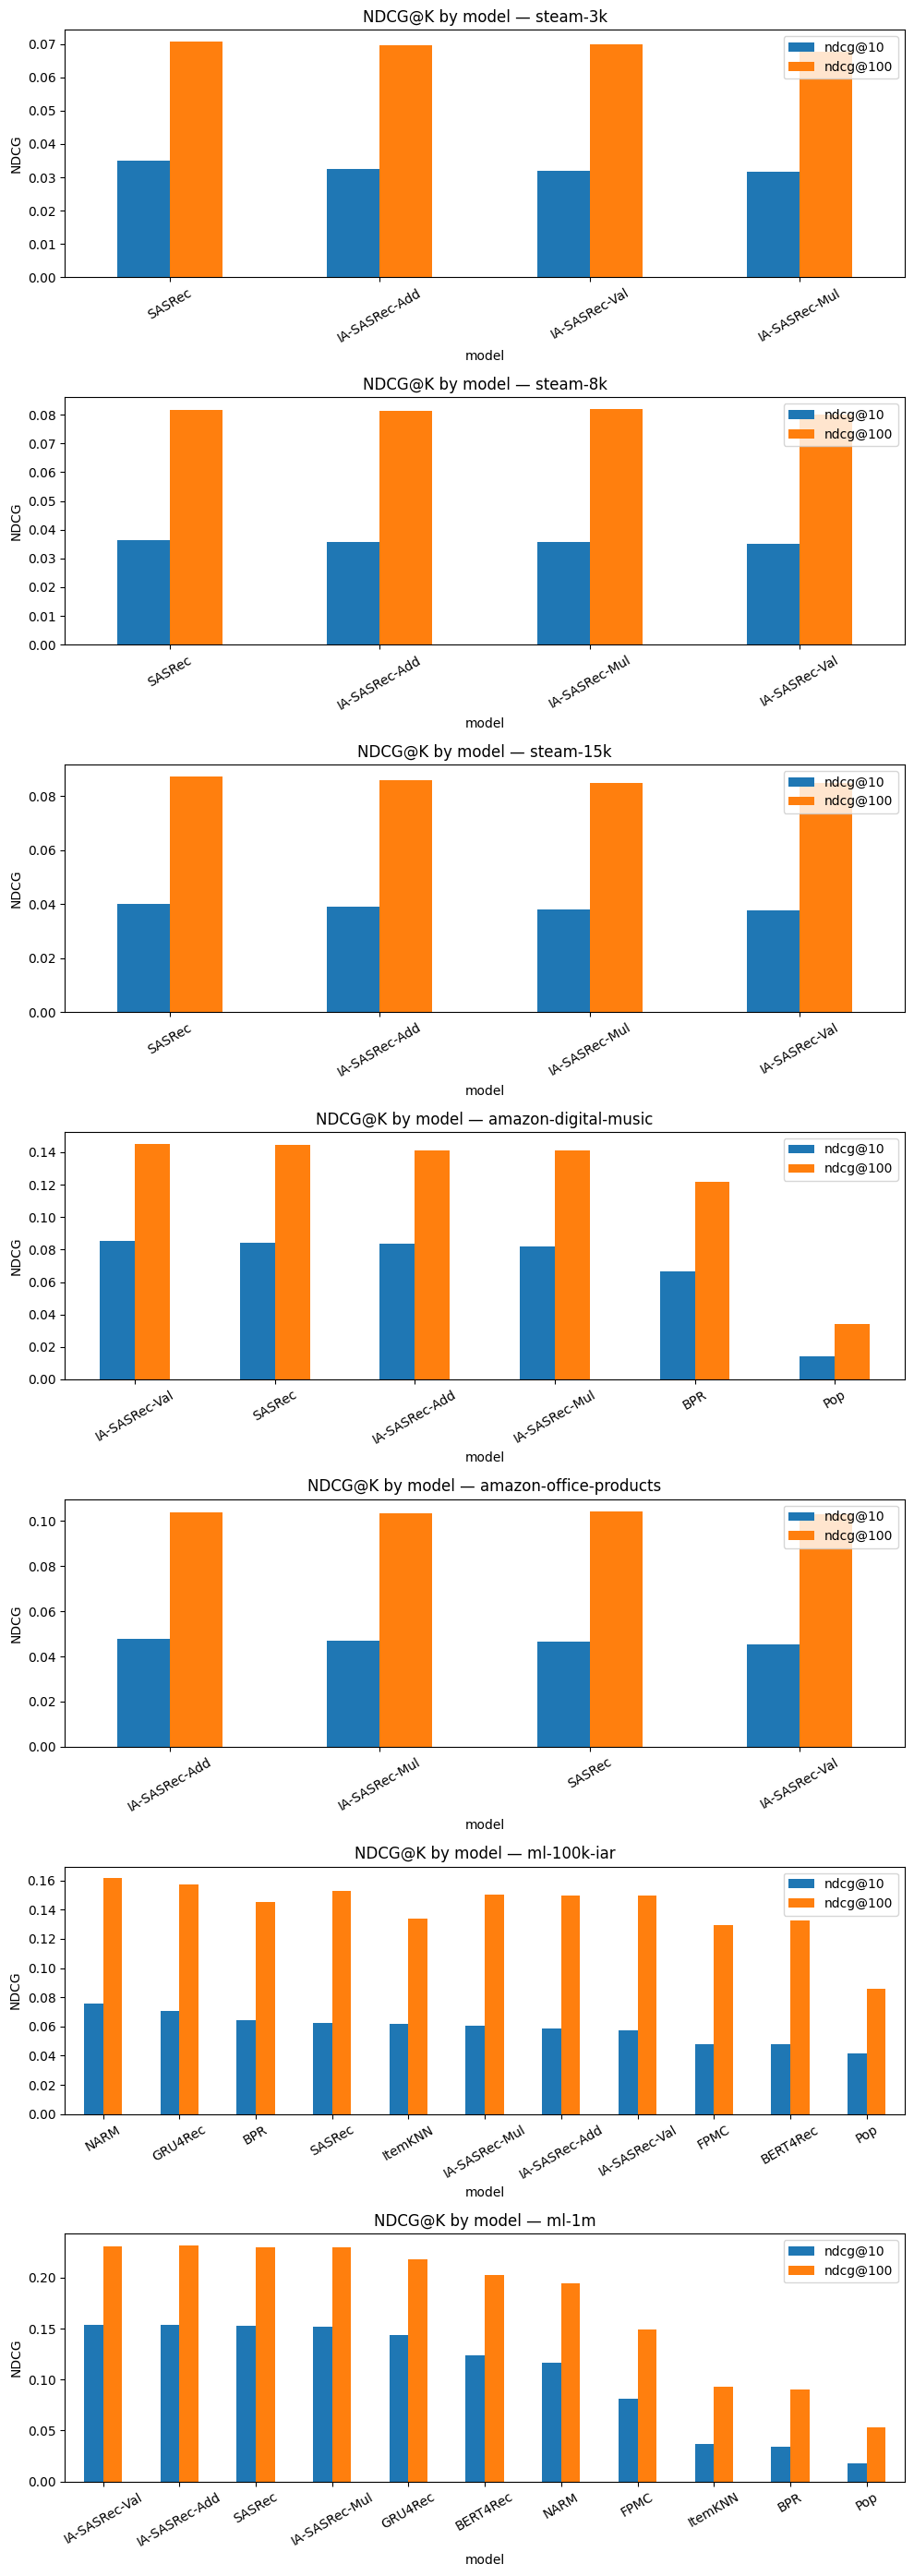

In [7]:
import matplotlib.pyplot as plt
ndcg_cols = ['ndcg@10', 'ndcg@20', 'ndcg@50', 'ndcg@100']
fig, axes = plt.subplots(len(tables), 1, figsize=(10, 4 * len(tables)), squeeze=False)
for ax, (ds, tbl) in zip(axes.flatten(), tables.items()):
    cols = [c for c in ndcg_cols if c in tbl.columns]
    tbl.set_index('model')[cols].plot.bar(ax=ax)
    ax.set_ylabel('NDCG'); ax.set_title(f'NDCG@K by model — {ds}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()

## 5. Top-100 recommendations demo

Confirms the "next-1 → top-K" path: for the best model on each dataset we
score the entire item vocab at the next position, mask items already in the
user's history, and take the top 100. Models are reloaded from their
checkpoints.

In [8]:
from pathlib import Path
import numpy as np
from recbole.utils import get_model, init_seed
from recbole.data import create_dataset, data_preparation
from runner import _build_config

topk_per_dataset = {}
for ds, tbl in tables.items():
    best_model_name = tbl.iloc[0]['model']
    print(f'\n=== {ds} | best model: {best_model_name} ===')
    rec = load_result(ds, best_model_name)
    # load_result returns a multi-seed aggregate; `checkpoint` lives on each
    # per-seed entry, not at the top level. Pick the first seed's checkpoint
    # (any seed works; we just need *a* trained model for the demo) and use
    # that seed for reproducible dataset/dataloader construction.
    per_seed = rec.get('per_seed') or []
    seed_rec = next((r for r in per_seed if r.get('checkpoint')), None)
    if seed_rec is None:
        print(f'  [skip] no per-seed checkpoint recorded for {ds}/{best_model_name}')
        continue
    ckpt = str(config.CHECKPOINT_DIR / Path(seed_rec['checkpoint']).name)
    seed = int(seed_rec.get('seed', config.LEGACY_SEED))

    overrides = dict(rec.get('best_params') or {})
    overrides['seed'] = seed
    cfg, model_cls = _build_config(ds, best_model_name, overrides, epochs=1, saved=False)
    init_seed(cfg['seed'], cfg['reproducibility'])
    dataset = create_dataset(cfg)
    train_data, valid_data, test_data = data_preparation(cfg, dataset)
    model_class = model_cls or get_model(cfg['model'])
    model = model_class(cfg, train_data._dataset).to(cfg['device'])
    model.load_state_dict(torch.load(ckpt, map_location=cfg['device'])['state_dict'])
    model.eval()

    sample_users = list(dataset.id2token(dataset.uid_field, np.arange(1, 4)))
    topk_per_dataset[ds] = top_k_recommend(model, dataset, test_data, sample_users, k=100)
    print(topk_per_dataset[ds].head(5).to_string(index=False))



=== steam-3k | best model: SASRec ===


Max value of user's history interaction records has reached 24.090338770388957% of the total.


  user_id  rank item_id    score
!Nicotine     1     440 1.796083
!Nicotine     2   49520 1.687827
!Nicotine     3  252490 1.639262
!Nicotine     4  377160 1.564325
!Nicotine     5  319630 1.447775

=== steam-8k | best model: SASRec ===
  user_id  rank item_id    score
!Nicotine     1  282140 4.571261
!Nicotine     2  319630 4.201891
!Nicotine     3   50300 3.991748
!Nicotine     4   49520 3.819047
!Nicotine     5  234140 3.575477

=== steam-15k | best model: SASRec ===
       user_id  rank item_id    score
!!! Vooper !!!     1  282140 4.195548
!!! Vooper !!!     2  377160 4.061244
!!! Vooper !!!     3  319630 3.848452
!!! Vooper !!!     4  337000 3.663267
!!! Vooper !!!     5  205100 3.573751

=== amazon-digital-music | best model: IA-SASRec-Val ===
             user_id  rank    item_id    score
A08161909WK3HU7UYTMW     1 B003JYOFIW 7.790260
A08161909WK3HU7UYTMW     2 B001QITO1Q 4.895010
A08161909WK3HU7UYTMW     3 B0026P3G12 4.889521
A08161909WK3HU7UYTMW     4 B001VPJZ40 4.885052
A081

Max value of user's history interaction records has reached 47.925925925925924% of the total.


user_id  rank item_id    score
      1     1     444 1.754580
      1     2     576 1.406417
      1     3     336 1.335033
      1     4     291 1.247698
      1     5     449 1.227659

=== ml-1m | best model: IA-SASRec-Val ===


Max value of user's history interaction records has reached 66.60813579163009% of the total.


user_id  rank item_id    score
      1     1    1094 4.251817
      1     2      32 4.223155
      1     3     348 4.044064
      1     4     319 3.912961
      1     5     535 3.872756


## 6. Analysis

In [9]:
rows = []
for ds, tbl in tables.items():
    is_seq = {n: (MODEL_REGISTRY[n]['type'] == 'sequential') for n in tbl['model']}
    family = tbl['model'].map(lambda n: 'sequential' if is_seq[n] else 'general')
    grouped = (
        tbl.assign(family=family)
           .groupby('family')[[c for c in ['ndcg@10', 'hit@10', 'mrr@10'] if c in tbl.columns]]
           .mean()
           .round(4)
    )
    grouped['dataset'] = ds
    rows.append(grouped.reset_index())
pd.concat(rows, ignore_index=True).set_index(['dataset', 'family'])

ndcg@10  hit@10  mrr@10
dataset                family                             
steam-3k               sequential   0.0328  0.0654  0.0230
steam-8k               sequential   0.0357  0.0750  0.0240
steam-15k              sequential   0.0386  0.0806  0.0260
amazon-digital-music   general      0.0405  0.0760  0.0297
                       sequential   0.0838  0.1793  0.0544
amazon-office-products sequential   0.0467  0.0970  0.0313
ml-100k-iar            general      0.0557  0.1064  0.0406
                       sequential   0.0600  0.1262  0.0404
ml-1m                  general      0.0297  0.0599  0.0207
                       sequential   0.1347  0.2460  0.1008

## 7. Adding a custom variant

For your next paper, drop a class into [`src/models/variants/`](../src/models/variants/)
and register it. Example:

```python
# src/models/variants/sasrec_plus.py
from recbole.model.sequential_recommender.sasrec import SASRec
import torch.nn as nn

class SASRecPlus(SASRec):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.extra_proj = nn.Linear(self.hidden_size, self.hidden_size)
    def forward(self, item_seq, item_seq_len):
        out = super().forward(item_seq, item_seq_len)
        return out + self.extra_proj(out)  # toy modification
```

Then in [`src/models/__init__.py`](../src/models/__init__.py):

```python
from models.variants.sasrec_plus import SASRecPlus
MODEL_REGISTRY['SASRecPlus'] = {
    'class': SASRecPlus,
    'type': 'sequential',
    'search_space': sasrec_space,
    'static': _seq_static(),
}
```

Re-run section 3 — only `SASRecPlus` will train; everything else loads from disk.